<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_13_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [57]:
veri = pd.read_csv("/content/spor_salonu_uyelik.csv")

In [58]:
veri.head()

,uye_no,yas,haftalik_ziyaret,uyelik_suresi_ay,aylik_ucret_tl,grup_dersi,yeniledi
0,1001,46.0,4,4,900,Hayır,Evet
1,1002,52.0,3,8,900,Evet,Evet
2,1003,18.0,1,15,900,Hayır,Hayır
3,1004,52.0,0,32,1200,Evet,Hayır
4,1005,38.0,3,11,900,Evet,Evet


In [59]:
veri.shape

(503, 7)

In [60]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uye_no            503 non-null    int64  
 1   yas               491 non-null    float64
 2   haftalik_ziyaret  503 non-null    int64  
 3   uyelik_suresi_ay  503 non-null    int64  
 4   aylik_ucret_tl    503 non-null    int64  
 5   grup_dersi        503 non-null    object 
 6   yeniledi          503 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 27.6+ KB


In [61]:
veri.isnull().sum() #yas sütununda eksik değerler olduğu tespit edildi.

,0
uye_no,0
yas,12
haftalik_ziyaret,0
uyelik_suresi_ay,0
aylik_ucret_tl,0
grup_dersi,0
yeniledi,0


In [62]:
veri.duplicated().sum() # 3 adet tekrarlayan satır varmış. Tespit edildi.

np.int64(3)

In [63]:
veri[veri.duplicated(keep=False)] # tekrarlayan satırları yazdırdık.

,uye_no,yas,haftalik_ziyaret,uyelik_suresi_ay,aylik_ucret_tl,grup_dersi,yeniledi
10,1011,29.0,4,5,900,Evet,Evet
11,1011,29.0,4,5,900,Evet,Evet
201,1201,26.0,4,16,1200,Evet,Evet
202,1201,26.0,4,16,1200,Evet,Evet
417,1416,35.0,4,2,1800,Evet,Evet
418,1416,35.0,4,2,1800,Evet,Evet


In [64]:
veri.describe()

,uye_no,yas,haftalik_ziyaret,uyelik_suresi_ay,aylik_ucret_tl
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,1250.254473,38.156823,2.669980,12.248509,1375.944334
std,144.650943,12.465211,1.460787,8.295337,430.136934
min,1001.000000,18.000000,0.000000,1.000000,900.000000
25%,1125.500000,28.000000,2.000000,6.000000,1050.000000
50%,1250.000000,37.000000,3.000000,11.000000,1200.000000
75%,1375.500000,49.000000,4.000000,17.000000,1500.000000
max,1500.000000,60.000000,7.000000,48.000000,2400.000000


In [65]:
# VERİYİ TEMİZLEME
veri = veri.drop_duplicates() # tekrar eden satırları sildirdik.
veri.shape # kontrol amaçlı verimizin şekline baktık. 3 satır silinmiş teyit ettik.

(500, 7)

In [66]:
ortanca_yas = veri["yas"].median()
ortanca_yas

37.0

In [67]:
#BOŞ DEĞERLERİ DOLDURACAĞIZ
veri["yas"] = veri["yas"].fillna(ortanca_yas) # boş değerleri ortanca yaş ile doldurduk.
veri.isnull().sum() # boş değer var mı kontrol ettik.

,0
uye_no,0
yas,0
haftalik_ziyaret,0
uyelik_suresi_ay,0
aylik_ucret_tl,0
grup_dersi,0
yeniledi,0


In [68]:
#HEDEF SÜTUNUMUZU İNCELİYORUZ.
sayilar = veri["yeniledi"].value_counts()
sayilar

,count
yeniledi,
Evet,301
Hayır,199


In [69]:
sayilar.oran = veri["yeniledi"].value_counts(normalize=True)
sayilar.oran

,proportion
yeniledi,
Evet,0.602
Hayır,0.398


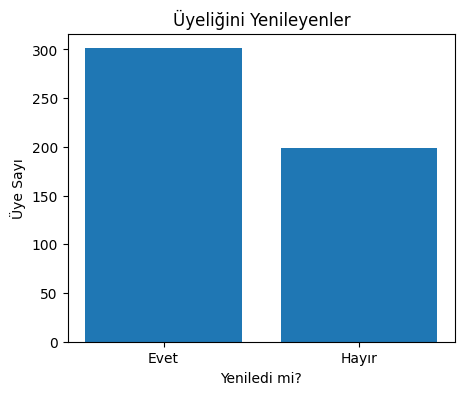

In [70]:
#VERİ GÖRSELLEŞTİRME # üyelerin %60,2 si üyeliğini yenilemiş, %39,8 i yenilememiş.

plt.figure(figsize=(5,4))
plt.bar(sayilar.index, sayilar.values)
plt.title("Üyeliğini Yenileyenler")
plt.xlabel("Yeniledi mi?")
plt.ylabel("Üye Sayı")
plt.savefig("yenileme_grafiği.png") # ürettiğimiz grafiği dışarı çıkarma.
plt.show()


In [71]:
veri['haftalik_ziyaret'].value_counts().sort_index()

,count
haftalik_ziyaret,
0,40
1,71
2,114
3,132
4,93
5,37
6,12
7,1


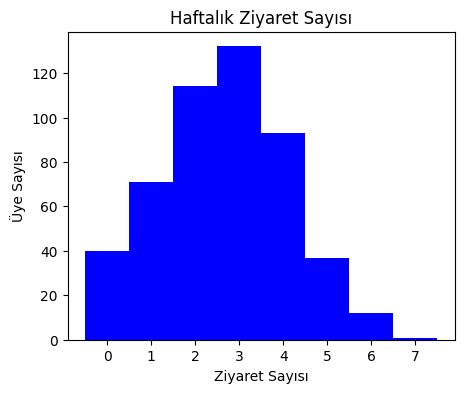

In [72]:
plt.figure(figsize=(5,4))
plt.hist(veri["haftalik_ziyaret"], bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5], color="b")
plt.title("Haftalık Ziyaret Sayısı")
plt.xlabel("Ziyaret Sayısı")
plt.ylabel("Üye Sayısı")
plt.savefig("ziyaret_grafiği.png")
plt.show()

In [73]:
veri.groupby("yeniledi")["haftalik_ziyaret"].mean()

,haftalik_ziyaret
yeniledi,
Evet,3.358804
Hayır,1.608040


In [74]:
#Data frame de baktığımızda grup_dersi sütunu object tipinde (metinsel ifade olarak yer alıyor). Algoritmaya öğretmeden önce sayısal ifadeye çevireceğiz.
veri = pd.get_dummies(veri, columns=["grup_dersi"], drop_first=True, dtype=int)
veri.head()

,uye_no,yas,haftalik_ziyaret,uyelik_suresi_ay,aylik_ucret_tl,yeniledi,grup_dersi_Hayır
0,1001,46.0,4,4,900,Evet,1
1,1002,52.0,3,8,900,Evet,0
2,1003,18.0,1,15,900,Hayır,1
3,1004,52.0,0,32,1200,Hayır,0
4,1005,38.0,3,11,900,Evet,0


In [81]:
#X ve Y olarak ayırabiliriz.
X = veri[["yas","haftalik_ziyaret","uyelik_suresi_ay","aylik_ucret_tl","grup_dersi_Hayır"]]
y = veri["yeniledi"]

In [82]:
#Train ve Test datası olarak ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [85]:
print("Eğitim:", X_train.shape)
print("Test:", X_test.shape)

Eğitim: (400, 5)
Test: (100, 5)


In [87]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [89]:
tahmin = model.predict(X_test)

In [91]:
accuracy_score(y_test, tahmin)

0.67

In [93]:
olcekleyici = StandardScaler()
X_train_scaled = olcekleyici.fit_transform(X_train)
X_test_scaled = olcekleyici.transform(X_test)

In [95]:
model_scaled = KNeighborsClassifier(n_neighbors=5)
model_scaled.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [97]:
tahmin = model_scaled.predict(X_test_scaled)

In [99]:
accuracy_score(y_test, tahmin)

0.94

In [101]:
confusion_matrix(y_test, tahmin)

array([[58,  2],
       [ 4, 36]])

In [102]:
k_listesi = [1,3,5,7,9,11,15,21,31,51,101,201,301] # k değerini farklı değerler atamak adına bir for döngüsü yazdık ve accuracyscorelarını karşılaştırdık.
dogruluklar = []

for k in k_listesi:
  deneme = KNeighborsClassifier(n_neighbors=k)
  deneme.fit(X_train_scaled, y_train)
  dogruluklar.append(accuracy_score(y_test, deneme.predict(X_test_scaled)))

sonuc = pd.DataFrame(data={"k":k_listesi, "dogruluk":dogruluklar})
sonuc

,k,dogruluk
0,1,0.87
1,3,0.90
2,5,0.94
3,7,0.93
4,9,0.93
5,11,0.91
6,15,0.90
7,21,0.88
8,31,0.88
9,51,0.87
